Saved to Helmholtz_Analytical_Single.h5


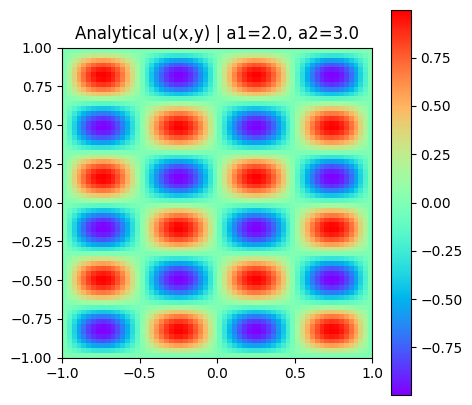

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

# 1. Setup the Grid: 64x64 from -1 to 1 (as defined in the paper)
nx, ny = 64, 64
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
X, Y = np.meshgrid(x, y, indexing='ij')

# 2. Pick a single case for the parameters (alpha_1, alpha_2)
alpha_1 = 2.0
alpha_2 = 3.0

# 3. Generate the Analytical Solution u(x,y) and Source Term h(x,y)
u_analytical = np.sin(alpha_1 * np.pi * X) * np.sin(alpha_2 * np.pi * Y)

# The source term h(x,y) based on the paper's formula
h_term = (1 - (alpha_1 * np.pi)**2 - (alpha_2 * np.pi)**2) * u_analytical

# 4. Save it into an HDF5 file so your notebook can read it easily
filename = "Helmholtz_Analytical_Single.h5"
with h5py.File(filename, 'w') as f:
    sample_grp = f.create_group("Sample_0")
    # Saving 'h' as 'a' just so it slots into your existing data pipeline
    sample_grp.create_dataset("a", data=h_term) 
    sample_grp.create_dataset("u", data=u_analytical)
    sample_grp.create_dataset("bc", data=0.0) # Boundary is 0 for sin(integer * pi * 1)

print(f"Saved to {filename}")

# 5. Visualize to confirm it looks like a wave
plt.figure(figsize=(5, 5))
plt.imshow(u_analytical.T, origin='lower', extent=[-1, 1, -1, 1], cmap='rainbow')
plt.title(f'Analytical u(x,y) | a1={alpha_1}, a2={alpha_2}')
plt.colorbar()
plt.show()